<a href="https://colab.research.google.com/github/andkacndra/TubesDataMining_Kelompok11/blob/main/Data_Cleaning_dan_Encoding_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving E-commerce Customer Behavior - Sheet1.csv to E-commerce Customer Behavior - Sheet1 (2).csv

--- Cek Missing Values ---
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

--- Cek Data Duplicate ---
Jumlah duplicate: 0
Jumlah duplicate setelah dihapus: 0

--- Analisis Kuartil, IQR, dan Visualisasi Outlier ---

Variabel: Age
  Kuartil 1 (Q1) : 30.0
  Kuartil 3 (Q3) : 37.0
  IQR            : 7.0
  Jumlah Outlier : 0 data

Variabel: Total Spend
  Kuartil 1 (Q1) : 505.75
  Kuartil 3 (Q3) : 1160.6
  IQR            : 654.8499999999999
  Jumlah Outlier : 0 data

Variabel: Items Purchased
  Kuartil 1 (Q1) : 9.0
  Kuartil 3 (Q3) : 15.0
  IQR            : 6.0
  Jumlah Outlier : 0 data

Variabel: Average

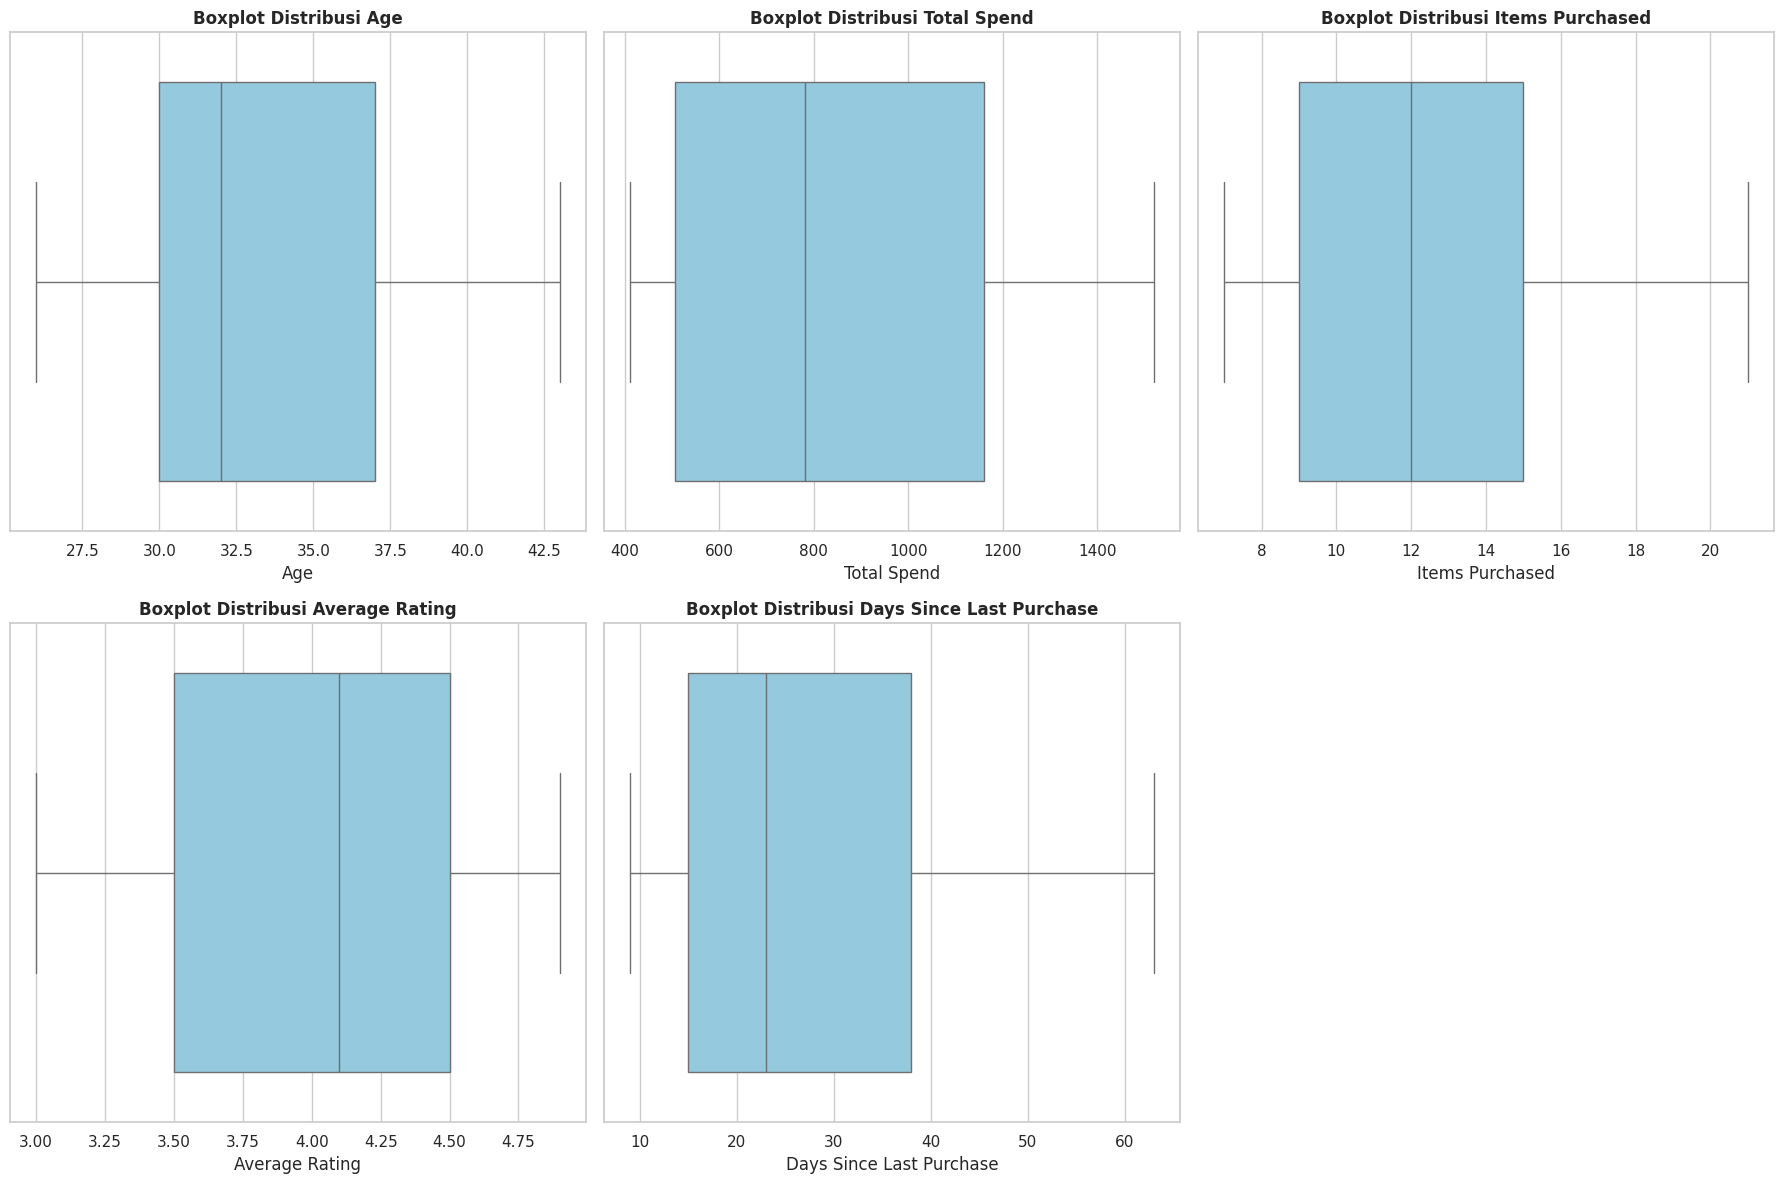

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Gender,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
0,0,29,3,1120.20,14,4.6,1,25,2,0,0,0,0,1,0
1,1,34,2,780.50,11,4.1,0,18,1,0,0,1,0,0,0
2,0,43,1,510.75,9,3.4,1,42,0,1,0,0,0,0,0
3,1,30,3,1480.30,19,4.7,0,12,2,0,0,0,0,0,1
4,1,27,2,720.40,13,4.0,1,55,0,0,0,0,1,0,0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("\n--- Cek Missing Values ---")
print(df.isnull().sum())
df_cleaned = df.dropna().copy()

print("\n--- Cek Data Duplicate ---")
print("Jumlah duplicate:", df_cleaned.duplicated().sum())
df_cleaned = df_cleaned.drop_duplicates()
print("Jumlah duplicate setelah dihapus:", df_cleaned.duplicated().sum())

print("\n--- Analisis Kuartil, IQR, dan Visualisasi Outlier ---")
kolom_numerik = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

for col in kolom_numerik:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    print(f"\nVariabel: {col}")
    print(f"  Kuartil 1 (Q1) : {Q1}")
    print(f"  Kuartil 3 (Q3) : {Q3}")
    print(f"  IQR            : {IQR}")
    print(f"  Jumlah Outlier : {len(outliers)} data")

plt.figure(figsize=(18, 12))
sns.set_theme(style="whitegrid")

for i, col in enumerate(kolom_numerik):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df_cleaned[col], color="skyblue", flierprops={"markerfacecolor":"red", "marker":"o"})
    plt.title(f'Boxplot Distribusi {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

plt.subplot(2, 3, 6).set_visible(False)

plt.tight_layout()
plt.show()

# Label Encoding untuk Gender & Discount (0 = female, 1 = male; 0 = Discount not applied, 1 = Discount applied)
le = LabelEncoder()
df_cleaned['Gender'] = le.fit_transform(df_cleaned['Gender'])
df_cleaned['Discount Applied'] = le.fit_transform(df_cleaned['Discount Applied'])

# Mengubah kolom Membership Type (Ordinal)
membership_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
df_cleaned['Membership Type'] = df_cleaned['Membership Type'].map(membership_map)

# Mengubah kolom Satisfaction Level (Target Prediksi)
satisfaction_map = {'Unsatisfied': 0, 'Neutral': 1, 'Satisfied': 2}
df_cleaned['Satisfaction Level'] = df_cleaned['Satisfaction Level'].map(satisfaction_map)

# Merubah kolom kota menjadi 1 jika customer tersebut berada di kota terkait
df_final = pd.get_dummies(df_cleaned, columns=['City'], dtype=int)

# Hapus ID Customer
if 'Customer ID' in df_final.columns:
    df_final = df_final.drop(columns=['Customer ID'])

output_name = 'E-commerce Customer Behavior Cleaned.csv'
df_final.to_csv(output_name, index=False)
files.download(output_name)
df_final.head()